## News analysis

In [1]:
# imports 
import pandas as pd
import ast
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotx


In [5]:
df = pd.read_csv('news_parsed.csv', index_col=0)


In [6]:
total = df.copy()

In [7]:
df = df[df['ai_related'] == 'yes']


In [8]:
total_lentgh = total.shape[0]
ai_length = df.shape[0]

print(f"Total articles: {total_lentgh}")
print(f"AI-related articles: {ai_length}")
print(f"Percentage of AI-related articles: {ai_length / total_lentgh * 100:.2f}%")

Total articles: 29091
AI-related articles: 9630
Percentage of AI-related articles: 33.10%


In [4]:
df.head()

,Unnamed: 0,title,outlet,date,authors,body,word_count,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits
102,102,Philips: Tekort aan specialisten breekt ons op...,TR,2018-11-24,"JOOST VAN VELZEN, REDACTIE ECONOMIE","Wie winkelt bij Bol.com, een liedje zoekt op S...",246,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,3,['tomtom']
107,107,Een butler om te wantrouwen of blij zijn met w...,TR,2018-07-31,"PETRA MODDERKOLK, REDACTIE BINNENLAND",Nu Google Assistent sinds vorige week Nederlan...,242,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,1,"['apple', 'google']"
108,108,Algoritme: géén natuurverschijnsel Algoritme: ...,TR,2018-09-18,"CATHY O'NEIL, UNIVERSITAIR HOOFDDOCENT LEIDEN,...",De onderzoekers waren stomverbaasd. Ze dachten...,221,yes,[],"['ai', 'kunstmatige intelligentie']","['ai', 'kunstmatige intelligentie']",0,5,[]
115,115,"Niet slimmer dan de mens, maar anders Niet sli...",TR,2018-10-06,INEZ POLAK,ideeën over de grens\nThe Atlantic\nIs een rob...,238,yes,[],"['ai', 'kunstmatige intelligentie']","['ai', 'kunstmatige intelligentie']",0,6,['google']
167,167,de ster die heet de ster die heet,TR,2018-12-22,HANS DE BRUIJN,Essay onbevangenheid\nAls er één ding is waar ...,241,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,2,[]


In [19]:
# make sure matched_keywords_all is list
for idx, row in df.iterrows():
    if isinstance(row['matched_keywords_all'], str):
        try:
            df.at[idx, 'matched_keywords_all'] = ast.literal_eval(row['matched_keywords_all'])
        except (ValueError, SyntaxError):
            df.at[idx, 'matched_keywords_all'] = []

In [20]:
df['matched_keywords_all'].iloc[0]

['kunstmatige intelligentie']

In [ ]:
# remove index
df = df.reset_index(drop=True)

# remove first column
df = df.iloc[:, 1:]
df.head()

,title,outlet,date,authors,body,word_count,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits
0,Philips: Tekort aan specialisten breekt ons op...,TR,2018-11-24,"JOOST VAN VELZEN, REDACTIE ECONOMIE","Wie winkelt bij Bol.com, een liedje zoekt op S...",246,yes,[],['kunstmatige intelligentie'],[kunstmatige intelligentie],0,3,['tomtom']
1,Een butler om te wantrouwen of blij zijn met w...,TR,2018-07-31,"PETRA MODDERKOLK, REDACTIE BINNENLAND",Nu Google Assistent sinds vorige week Nederlan...,242,yes,[],['kunstmatige intelligentie'],[kunstmatige intelligentie],0,1,"['apple', 'google']"
2,Algoritme: géén natuurverschijnsel Algoritme: ...,TR,2018-09-18,"CATHY O'NEIL, UNIVERSITAIR HOOFDDOCENT LEIDEN,...",De onderzoekers waren stomverbaasd. Ze dachten...,221,yes,[],"['ai', 'kunstmatige intelligentie']","[ai, kunstmatige intelligentie]",0,5,[]
3,"Niet slimmer dan de mens, maar anders Niet sli...",TR,2018-10-06,INEZ POLAK,ideeën over de grens\nThe Atlantic\nIs een rob...,238,yes,[],"['ai', 'kunstmatige intelligentie']","[ai, kunstmatige intelligentie]",0,6,['google']
4,de ster die heet de ster die heet,TR,2018-12-22,HANS DE BRUIJN,Essay onbevangenheid\nAls er één ding is waar ...,241,yes,[],['kunstmatige intelligentie'],[kunstmatige intelligentie],0,2,[]


In [27]:
# add total word count of body column
df['relevant_len_words'] = df['body'].str.count(r'\b\w+\b')

In [ ]:
_COMPANY_NAMES = [
    "NVIDIA", "Apple", "Microsoft", "Google", "Alphabet",
    "Meta Platforms", "Facebook", "Tesla", "Oracle",
    "Palantir", "IBM", "Adobe", "Cambricon Technologies",
    "CoreWeave", "Fermi Inc", "Dynatrace", "Tempus AI",
    "SenseTime", "Mobileye", "Aurora Innovation", "UiPath",
    "SoundHound AI", "ASML", "NXP Semiconductors",
    "BE Semiconductor Industries", "ASM International",
    "Adyen", "Just Eat Takeaway", "Booking.com", "Mollie",
    "Picnic", "TomTom", "Swapfiets", "TKH Group",
    "Ordina", "Nedap", "CM.com", "ICT Group",
    "Neways Electronics", "Ctac", "Photon Energy",
    "Almunda Professionals", "Samsung", "Huawei",
    "Sony", "LG", "Baidu", "Tencent",
    "Alibaba", "Douyin", "Cloudflare",
    "Snowflake", "Docker", "Red Hat",
    "Uber", "Bolt", "Grab", "Epic Games",
    "Unity", "Discord"
]

# Precompile regex patterns for each company for efficiency
COMPANY_PATTERNS = {name: re.compile(rf'\b{re.escape(name)}\b', re.IGNORECASE) for name in _COMPANY_NAMES}

def company_counts_exact(text):
    if not isinstance(text, str):
        text = ""
    counts = Counter()
    for name, pattern in COMPANY_PATTERNS.items():
        count = len(pattern.findall(text))
        if count > 0:
            counts[name] = count
    return counts

# Apply function
df['company_hits'] = df['body'].apply(company_counts_exact)

# Total mentions per row
df['n_company_hits'] = df['company_hits'].apply(lambda x: sum(x.values()))

# # Inspect
# print(df[['body', 'company_hits', 'n_company_hits']].head())


In [30]:
df.head()

,title,outlet,date,authors,body,word_count,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits,relevant_len_words,n_company_hits
0,Philips: Tekort aan specialisten breekt ons op...,TR,2018-11-24,"JOOST VAN VELZEN, REDACTIE ECONOMIE","Wie winkelt bij Bol.com, een liedje zoekt op S...",246,yes,[],['kunstmatige intelligentie'],[kunstmatige intelligentie],0,3,{'TomTom': 1},252,1
1,Een butler om te wantrouwen of blij zijn met w...,TR,2018-07-31,"PETRA MODDERKOLK, REDACTIE BINNENLAND",Nu Google Assistent sinds vorige week Nederlan...,242,yes,[],['kunstmatige intelligentie'],[kunstmatige intelligentie],0,1,"{'Apple': 1, 'Google': 7}",243,8
2,Algoritme: géén natuurverschijnsel Algoritme: ...,TR,2018-09-18,"CATHY O'NEIL, UNIVERSITAIR HOOFDDOCENT LEIDEN,...",De onderzoekers waren stomverbaasd. Ze dachten...,221,yes,[],"['ai', 'kunstmatige intelligentie']","[ai, kunstmatige intelligentie]",0,5,{},221,0
3,"Niet slimmer dan de mens, maar anders Niet sli...",TR,2018-10-06,INEZ POLAK,ideeën over de grens\nThe Atlantic\nIs een rob...,238,yes,[],"['ai', 'kunstmatige intelligentie']","[ai, kunstmatige intelligentie]",0,6,{'Google': 1},244,1
4,de ster die heet de ster die heet,TR,2018-12-22,HANS DE BRUIJN,Essay onbevangenheid\nAls er één ding is waar ...,241,yes,[],['kunstmatige intelligentie'],[kunstmatige intelligentie],0,2,{},242,0


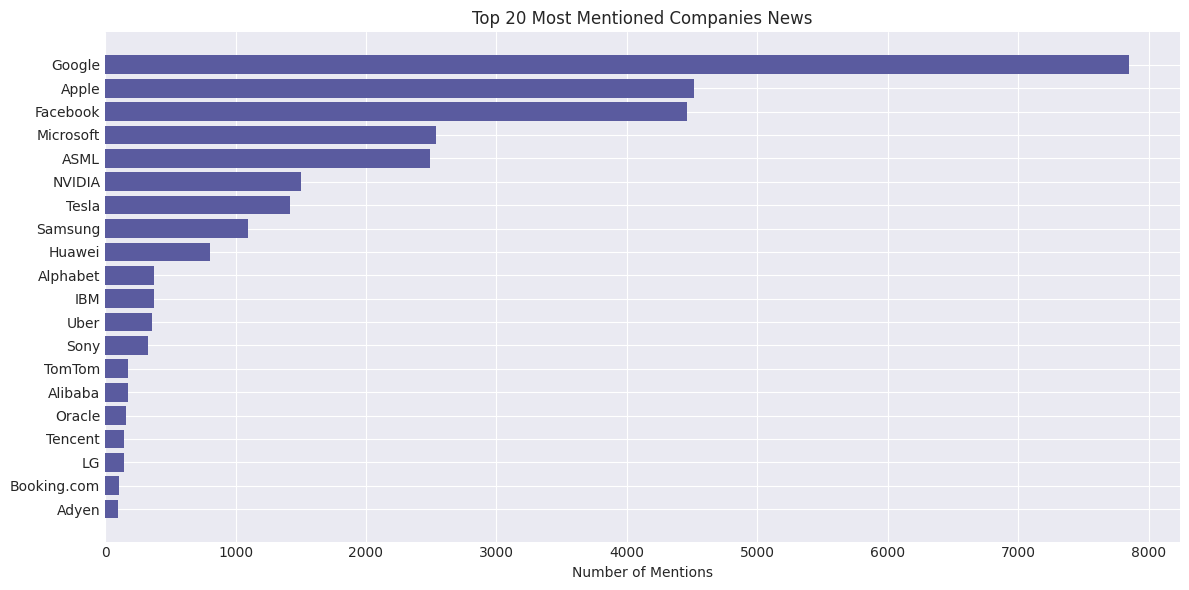

In [ ]:
# Aggregate counts across all rows
total_counts = Counter()
for hits in df['company_hits']:
    total_counts.update(hits)

# Convert to DataFrame for plotting
company_counts_df = pd.DataFrame(total_counts.items(), columns=['Company', 'Mentions'])
company_counts_df = company_counts_df.sort_values(by='Mentions', ascending=False)

# Plot top 20 companies
top_n = 20
plt.figure(figsize=(12,6))
plt.style.use(matplotx.styles.pacoty)
plt.barh(
    company_counts_df['Company'][:top_n][::-1],  # reverse for largest on top
    company_counts_df['Mentions'][:top_n][::-1],
)
plt.xlabel("Number of Mentions")
plt.title(f"Top {top_n} Most Mentioned Companies News")
plt.tight_layout()
plt.show()


C:\Users\joly-\AppData\Local\Temp\ipykernel_12392\16300636.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  outlet_df = pd.DataFrame(index=outlet_counts.keys(), columns=all_companies).fillna(0)


<Figure size 1200x800 with 0 Axes>

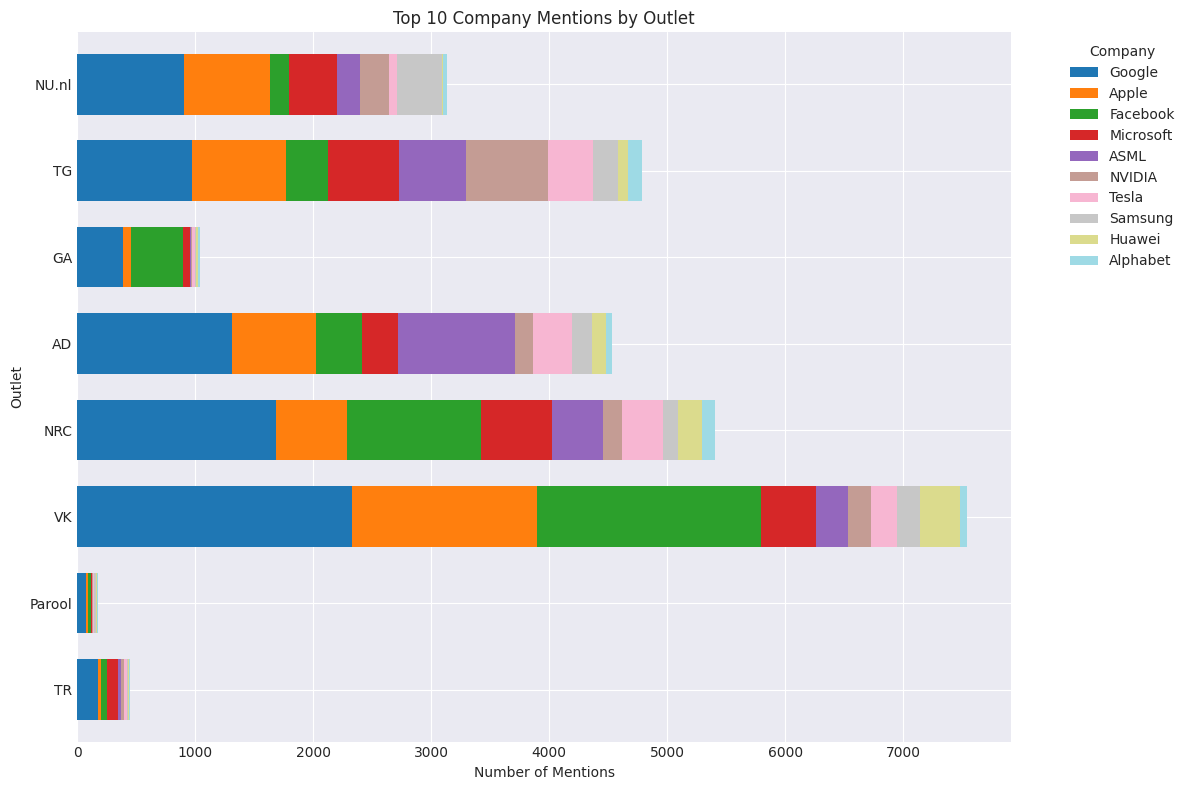

In [34]:
# 1. Aggregate company mentions per outlet
outlet_counts = {}
for outlet, hits in zip(df['outlet'], df['company_hits']):
    if outlet not in outlet_counts:
        outlet_counts[outlet] = Counter()
    outlet_counts[outlet].update(hits)

# 2. Convert to DataFrame: rows = outlets, columns = companies
all_companies = set()
for counts in outlet_counts.values():
    all_companies.update(counts.keys())
all_companies = list(all_companies)

outlet_df = pd.DataFrame(index=outlet_counts.keys(), columns=all_companies).fillna(0)
for outlet, counts in outlet_counts.items():
    for company, count in counts.items():
        outlet_df.at[outlet, company] = count

# 3. Keep top N companies overall for readability
top_n = 10
top_companies = outlet_df.sum().sort_values(ascending=False).head(top_n).index
outlet_df_top = outlet_df[top_companies]

# 4. Plot stacked horizontal bar chart
plt.figure(figsize=(12,8))
plt.style.use(matplotx.styles.pacoty)
outlet_df_top.plot(
    kind='barh',
    stacked=True,
    figsize=(12,8),
    width=0.7,
    colormap='tab20'
)
plt.xlabel("Number of Mentions")
plt.ylabel("Outlet")
plt.title(f"Top {top_n} Company Mentions by Outlet")
plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
